
# 🦷 Oral Disease Image Classification — Full Project

**Custom CNN + 3 pretrained transfer-learning models, hyperparameter tuning,
comparative analysis, and Gradio deployment.**

Dataset: [Oral Diseases](https://www.kaggle.com/datasets/salmansajid05/oral-diseases) (Salman Sajid) —
6 classes, ~12,653 intraoral images: Calculus, Caries, Gingivitis, Hypodontia,
Tooth Discoloration, Ulcers.



## 0. Setup

In [5]:

import os, sys, json, time, glob, itertools, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:

!pip install -q gradio==6.20.0
import gradio as gr
print("Gradio:", gr.__version__)


Gradio: 6.20.0


## 1. Locate the dataset

In [7]:

CANDIDATE_ROOTS = [
    "/kaggle/input/datasets/salmansajid05/oral-diseases",
    "/kaggle/input/oral-diseases",
]

def print_tree(path, max_depth=3, prefix=""):
    if max_depth < 0 or not os.path.isdir(path):
        return
    entries = sorted(os.listdir(path))[:20]
    for e in entries:
        full = os.path.join(path, e)
        print(prefix + ("📁 " if os.path.isdir(full) else "📄 ") + e)
        if os.path.isdir(full):
            print_tree(full, max_depth-1, prefix + "    ")

print("=== /kaggle/input tree ===")
print_tree("/kaggle/input", max_depth=3)


=== /kaggle/input tree ===
📁 datasets
    📁 salmansajid05
        📁 oral-diseases
            📁 Calculus
            📁 Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
            📁 Data caries
            📁 Gingivitis
            📁 Mouth Ulcer
            📁 Tooth Discoloration
            📁 hypodontia


In [10]:

def find_image_folder_root(root, min_classes=3, min_images_per_class=20):
    '''Walk the tree looking for a directory whose immediate subfolders each
    contain many images -- that's our ImageFolder-style class root.'''
    for dirpath, dirnames, filenames in os.walk(root):
        if len(dirnames) >= min_classes:
            ok = 0
            for d in dirnames:
                sub = os.path.join(dirpath, d)
                n_images = sum(
                    1 for f in os.listdir(sub)
                    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
                )
                if n_images >= min_images_per_class:
                    ok += 1
            if ok >= min_classes:
                return dirpath
    return None

DATA_DIR = '/kaggle/input/datasets/salmansajid05/oral-diseases'
for root in CANDIDATE_ROOTS:
    if os.path.isdir(root):
        found = find_image_folder_root(root)
        if found:
            DATA_DIR = found
            break
if DATA_DIR is None:
    found = find_image_folder_root("/kaggle/input/datasets/salmansajid05/oral-diseases")
    if found:
        DATA_DIR = found

if DATA_DIR is None:
    raise RuntimeError(
        "Could not auto-detect the class-folder structure. "
        "Look at the printed tree above and set DATA_DIR manually, e.g.:\n"
        "DATA_DIR = '/kaggle/input/datasets/salmansajid05/oral-diseases'"
    )

print("Using DATA_DIR =", DATA_DIR)
print("Classes found:", sorted(os.listdir(DATA_DIR)))


Using DATA_DIR = /kaggle/input/datasets/salmansajid05/oral-diseases
Classes found: ['Calculus', 'Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia']


## 2. Configuration

In [11]:

IMG_SIZE = 160
IMG_CHANNELS = 3
BATCH_SIZE = 32

VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

EPOCHS_CUSTOM_CNN = 30
EPOCHS_HEAD = 10
EPOCHS_FINE_TUNE = 8
EARLY_STOPPING_PATIENCE = 6
TUNE_EPOCHS = 5   # short probe epochs for hyperparameter search trials

PRETRAINED_MODELS = ["MobileNetV2", "EfficientNetB0", "ResNet50"]

OUT_DIR = "/kaggle/working/outputs"
CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")
LOG_DIR = os.path.join(OUT_DIR, "logs")
FIG_DIR = os.path.join(OUT_DIR, "figures")
REPORT_DIR = os.path.join(OUT_DIR, "reports")
for d in [CKPT_DIR, LOG_DIR, FIG_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)


## 3. Exploratory Data Analysis

Total images: 13862 across 7 classes


,class,count
0,Calculus,1296
1,Caries_Gingivitus_ToothDiscoloration_Ulcer-yol...,1542
2,Data caries,2601
3,Gingivitis,2349
4,Mouth Ulcer,2806
5,Tooth Discoloration,2017
6,hypodontia,1251


/tmp/ipykernel_58/90726702.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_df, x="class", y="count", ax=ax, palette="viridis")


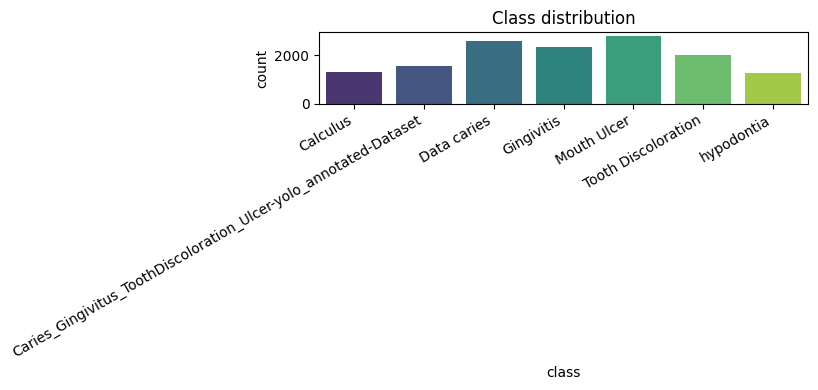

In [12]:

VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def collect_class_images(data_dir):
    '''Recursively collects images under each immediate subfolder of data_dir.
    Handles datasets where images sit directly inside the class folder OR one
    (or more) levels deeper (e.g. ClassName/ClassName/*.jpg). Classes that end
    up with zero images are dropped and reported, rather than crashing later.'''
    candidate_classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    filepaths, labels, class_names = [], [], []
    dropped = []
    class_idx = 0
    for cls in candidate_classes:
        cls_dir = os.path.join(data_dir, cls)
        files = [
            f for f in glob.glob(os.path.join(cls_dir, "**", "*"), recursive=True)
            if os.path.isfile(f) and f.lower().endswith(VALID_EXT)
        ]
        if len(files) == 0:
            dropped.append(cls)
            continue
        filepaths.extend(files)
        labels.extend([class_idx] * len(files))
        class_names.append(cls)
        class_idx += 1

    if dropped:
        print(f"NOTE: {len(dropped)} folder(s) under DATA_DIR had no images and were skipped: {dropped}")
        print("      (if one of these was actually meant to be a class, inspect its contents with print_tree)")

    return np.array(filepaths), np.array(labels), class_names

filepaths, labels, class_names = collect_class_images(DATA_DIR)

print(f"Total images: {len(filepaths)} across {len(class_names)} classes")
counts = pd.Series(labels).value_counts().sort_index()
dist_df = pd.DataFrame({"class": class_names, "count": [counts.get(i,0) for i in range(len(class_names))]})
display(dist_df)

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=dist_df, x="class", y="count", ax=ax, palette="viridis")
ax.set_title("Class distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), dpi=150)
plt.show()


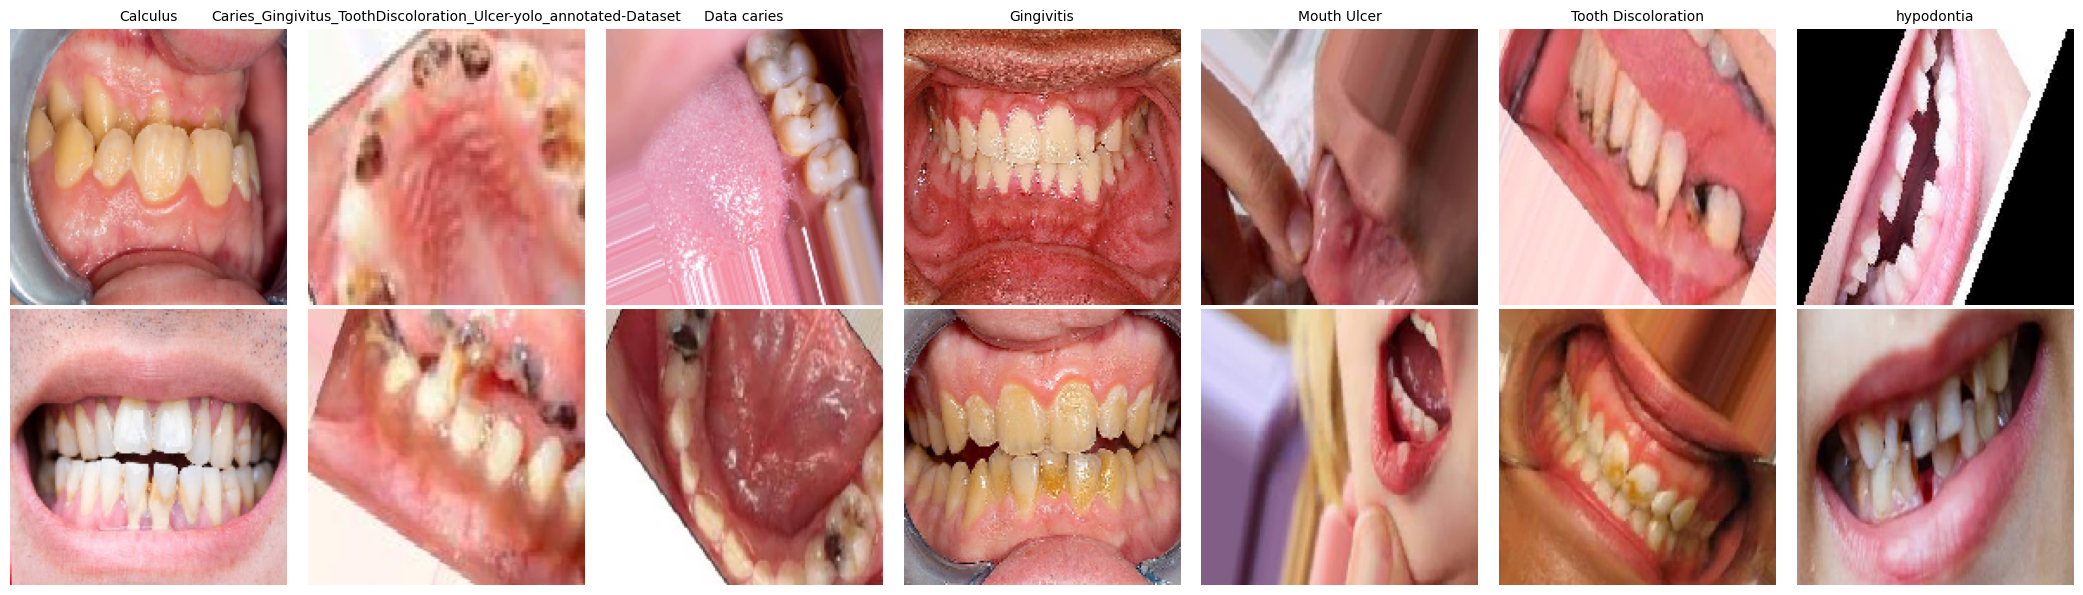

In [13]:

# Sample images grid
fig, axes = plt.subplots(2, len(class_names), figsize=(3*len(class_names), 6))
rng = np.random.RandomState(SEED)
for i, cls in enumerate(class_names):
    cls_files = filepaths[labels == i]
    n_show = min(2, len(cls_files))
    if n_show == 0:
        continue
    chosen = rng.choice(cls_files, size=n_show, replace=False)
    for j in range(2):
        ax = axes[j, i] if len(class_names) > 1 else axes[j]
        if j < len(chosen):
            img = tf.keras.utils.load_img(chosen[j], target_size=(160,160))
            ax.imshow(img)
            if j == 0:
                ax.set_title(cls, fontsize=10)
        ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sample_images.png"), dpi=150)
plt.show()


## 4. Data pipeline: stratified split + augmentation

In [14]:

def stratified_split(filepaths, labels, val_split=VAL_SPLIT, test_split=TEST_SPLIT, seed=SEED):
    train_fp, temp_fp, train_lb, temp_lb = train_test_split(
        filepaths, labels, test_size=(val_split+test_split), stratify=labels, random_state=seed)
    rel_test = test_split / (val_split+test_split)
    val_fp, test_fp, val_lb, test_lb = train_test_split(
        temp_fp, temp_lb, test_size=rel_test, stratify=temp_lb, random_state=seed)
    return (train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb)

(train_fp, train_lb), (val_fp, val_lb), (test_fp, test_lb) = stratified_split(filepaths, labels)
print(f"Train: {len(train_fp)}  Val: {len(val_fp)}  Test: {len(test_fp)}")

def compute_class_weights(labels, num_classes):
    counts = np.bincount(labels, minlength=num_classes)
    total = counts.sum()
    weights = total / (num_classes * np.maximum(counts, 1))
    return {i: float(w) for i, w in enumerate(weights)}

class_weights = compute_class_weights(train_lb, len(class_names))
print("Class weights (imbalance correction):", class_weights)

def _load_and_preprocess(path, label, augment):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
        img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    return img, label

def make_dataset(fps, lbs, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((fps, lbs))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(fps), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p,l: _load_and_preprocess(p,l,augment), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_fp, train_lb, augment=True, shuffle=True)
val_ds   = make_dataset(val_fp, val_lb, augment=False, shuffle=False)
test_ds  = make_dataset(test_fp, test_lb, augment=False, shuffle=False)

with open(os.path.join(REPORT_DIR, "dataset_meta.json"), "w") as f:
    json.dump({"class_names": class_names, "n_train": len(train_fp),
               "n_val": len(val_fp), "n_test": len(test_fp),
               "class_weights": class_weights}, f, indent=2)


Train: 9703  Val: 2079  Test: 2080
Class weights (imbalance correction): {0: 1.5282721688454874, 1: 1.2846551039322123, 2: 0.7611987134227661, 3: 0.8431525895029545, 4: 0.7057753855106197, 5: 0.9816875758802105, 6: 1.58235485975212}


I0000 00:00:1784076444.810581      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784076444.813489      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 5. Custom CNN (built from scratch)

In [15]:

from tensorflow.keras import layers, models, regularizers

def build_custom_cnn(input_shape, num_classes, conv_blocks=4, base_filters=32,
                      dropout_rate=0.4, dense_units=256, l2_reg=1e-4, learning_rate=1e-3):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    filters = base_filters
    for i in range(conv_blocks):
        x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(min(0.1 + i*0.05, 0.3))(x)
        filters = min(filters*2, 256)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs, name="CustomCNN")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")])
    return model

build_custom_cnn((IMG_SIZE,IMG_SIZE,3), len(class_names)).summary()


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,244,711 (4.75 MB)

 Trainable params: 1,242,279 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

## 6. Pretrained transfer-learning models

MobileNetV2, EfficientNetB0, ResNet50 — standard ImageNet weights (Kaggle has internet access, so the normal automatic download works here).

In [16]:

BACKBONES = {
    "MobileNetV2": {
        "constructor": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "fine_tune_at_fraction": 0.7,
    },
    "EfficientNetB0": {
        "constructor": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "fine_tune_at_fraction": 0.8,
    },
    "ResNet50": {
        "constructor": tf.keras.applications.ResNet50,
        "preprocess": tf.keras.applications.resnet50.preprocess_input,
        "fine_tune_at_fraction": 0.8,
    },
}

def build_transfer_model(backbone_name, input_shape, num_classes,
                          dense_units=128, dropout_rate=0.3, learning_rate=1e-3):
    cfg = BACKBONES[backbone_name]
    base = cfg["constructor"](include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(255.0)(inputs)
    x = cfg["preprocess"](x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs, name=f"{backbone_name}_transfer")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")])
    return model, base

def unfreeze_for_fine_tuning(model, base, backbone_name, learning_rate=1e-5):
    cfg = BACKBONES[backbone_name]
    base.trainable = True
    n_layers = len(base.layers)
    freeze_until = int(n_layers * cfg["fine_tune_at_fraction"])
    for layer in base.layers[:freeze_until]:
        layer.trainable = False
    for layer in base.layers[freeze_until:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")])
    return model

print("Backbones ready:", list(BACKBONES.keys()))


Backbones ready: ['MobileNetV2', 'EfficientNetB0', 'ResNet50']


## 7. Hyperparameter tuning


In [17]:

CUSTOM_CNN_SEARCH_SPACE = [
    {"conv_blocks": 3, "base_filters": 32, "dropout_rate": 0.3, "dense_units": 128, "learning_rate": 1e-3},
    {"conv_blocks": 4, "base_filters": 32, "dropout_rate": 0.4, "dense_units": 256, "learning_rate": 1e-3},
    {"conv_blocks": 4, "base_filters": 32, "dropout_rate": 0.4, "dense_units": 256, "learning_rate": 5e-4},
    {"conv_blocks": 4, "base_filters": 64, "dropout_rate": 0.5, "dense_units": 256, "learning_rate": 5e-4},
    {"conv_blocks": 5, "base_filters": 32, "dropout_rate": 0.5, "dense_units": 128, "learning_rate": 1e-3},
    {"conv_blocks": 3, "base_filters": 64, "dropout_rate": 0.3, "dense_units": 128, "learning_rate": 1e-4},
]

PRETRAINED_SEARCH_SPACE = [
    {"dense_units": 128, "dropout_rate": 0.3, "learning_rate": 1e-3},
    {"dense_units": 256, "dropout_rate": 0.4, "learning_rate": 1e-3},
    {"dense_units": 128, "dropout_rate": 0.5, "learning_rate": 5e-4},
    {"dense_units": 256, "dropout_rate": 0.3, "learning_rate": 5e-4},
]

def log_result(csv_path, row, fieldnames):
    write_header = not os.path.exists(csv_path)
    with open(csv_path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        if write_header: w.writeheader()
        w.writerow(row)

def tune_custom_cnn():
    csv_path = os.path.join(REPORT_DIR, "hparam_search_custom_cnn.csv")
    fieldnames = list(CUSTOM_CNN_SEARCH_SPACE[0].keys()) + ["val_accuracy","val_loss","train_time_sec"]
    best = None
    for i, cfg in enumerate(CUSTOM_CNN_SEARCH_SPACE):
        print(f"[custom_cnn] Trial {i+1}/{len(CUSTOM_CNN_SEARCH_SPACE)}: {cfg}")
        t0=time.time()
        m = build_custom_cnn((IMG_SIZE,IMG_SIZE,3), len(class_names), **cfg)
        h = m.fit(train_ds, validation_data=val_ds, epochs=TUNE_EPOCHS, verbose=0)
        elapsed=time.time()-t0
        val_acc=max(h.history["val_accuracy"]); val_loss=min(h.history["val_loss"])
        row=dict(cfg); row.update({"val_accuracy":val_acc,"val_loss":val_loss,"train_time_sec":round(elapsed,1)})
        log_result(csv_path,row,fieldnames)
        print(f"  -> val_acc={val_acc:.4f}  time={elapsed:.1f}s")
        if best is None or val_acc>best[1]: best=(cfg,val_acc)
    with open(os.path.join(REPORT_DIR,"best_config_custom_cnn.json"),"w") as f:
        json.dump(best[0], f, indent=2)
    print("BEST custom_cnn:", best[0], "val_acc=", best[1])
    return best[0]

def tune_pretrained(name):
    csv_path = os.path.join(REPORT_DIR, f"hparam_search_{name}.csv")
    fieldnames = list(PRETRAINED_SEARCH_SPACE[0].keys()) + ["val_accuracy","val_loss","train_time_sec"]
    best=None
    for i, cfg in enumerate(PRETRAINED_SEARCH_SPACE):
        print(f"[{name}] Trial {i+1}/{len(PRETRAINED_SEARCH_SPACE)}: {cfg}")
        t0=time.time()
        m, base = build_transfer_model(name, (IMG_SIZE,IMG_SIZE,3), len(class_names), **cfg)
        h = m.fit(train_ds, validation_data=val_ds, epochs=TUNE_EPOCHS, verbose=0)
        elapsed=time.time()-t0
        val_acc=max(h.history["val_accuracy"]); val_loss=min(h.history["val_loss"])
        row=dict(cfg); row.update({"val_accuracy":val_acc,"val_loss":val_loss,"train_time_sec":round(elapsed,1)})
        log_result(csv_path,row,fieldnames)
        print(f"  -> val_acc={val_acc:.4f}  time={elapsed:.1f}s")
        if best is None or val_acc>best[1]: best=(cfg,val_acc)
    with open(os.path.join(REPORT_DIR,f"best_config_{name}.json"),"w") as f:
        json.dump(best[0], f, indent=2)
    print(f"BEST {name}:", best[0], "val_acc=", best[1])
    return best[0]

best_custom_cnn_cfg = tune_custom_cnn()
best_pretrained_cfgs = {}
for name in PRETRAINED_MODELS:
    best_pretrained_cfgs[name] = tune_pretrained(name)


[custom_cnn] Trial 1/6: {'conv_blocks': 3, 'base_filters': 32, 'dropout_rate': 0.3, 'dense_units': 128, 'learning_rate': 0.001}


2026-07-15 00:48:09.564148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 00:48:09.717844: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 00:48:11.496719: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 00:48:11.793293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1784076499.010938     171 device_compiler.h:196]

  -> val_acc=0.5878  time=149.4s
[custom_cnn] Trial 2/6: {'conv_blocks': 4, 'base_filters': 32, 'dropout_rate': 0.4, 'dense_units': 256, 'learning_rate': 0.001}
  -> val_acc=0.4892  time=169.4s
[custom_cnn] Trial 3/6: {'conv_blocks': 4, 'base_filters': 32, 'dropout_rate': 0.4, 'dense_units': 256, 'learning_rate': 0.0005}
  -> val_acc=0.5926  time=169.5s
[custom_cnn] Trial 4/6: {'conv_blocks': 4, 'base_filters': 64, 'dropout_rate': 0.5, 'dense_units': 256, 'learning_rate': 0.0005}


2026-07-15 00:56:25.400141: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 00:56:25.603443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 00:56:26.874158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 00:56:27.051626: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 00:56:29.453938: E external/local_xla/xla/stream_

  -> val_acc=0.6229  time=374.1s
[custom_cnn] Trial 5/6: {'conv_blocks': 5, 'base_filters': 32, 'dropout_rate': 0.5, 'dense_units': 128, 'learning_rate': 0.001}
  -> val_acc=0.5738  time=188.5s
[custom_cnn] Trial 6/6: {'conv_blocks': 3, 'base_filters': 64, 'dropout_rate': 0.3, 'dense_units': 128, 'learning_rate': 0.0001}
  -> val_acc=0.6186  time=310.9s
BEST custom_cnn: {'conv_blocks': 4, 'base_filters': 64, 'dropout_rate': 0.5, 'dense_units': 256, 'learning_rate': 0.0005} val_acc= 0.6228955984115601
[MobileNetV2] Trial 1/4: {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-07-15 01:10:57.096325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 01:10:57.245155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 01:10:57.382107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 01:11:16.557161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 01:11:16.693072: E external/local_xla/xla/stream_

  -> val_acc=0.7513  time=90.1s
[MobileNetV2] Trial 2/4: {'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001}
  -> val_acc=0.7609  time=66.0s
[MobileNetV2] Trial 3/4: {'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.0005}
  -> val_acc=0.7494  time=65.6s
[MobileNetV2] Trial 4/4: {'dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005}
  -> val_acc=0.7609  time=66.8s
BEST MobileNetV2: {'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001} val_acc= 0.7609427571296692
[EfficientNetB0] Trial 1/4: {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-07-15 01:15:45.972287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 01:15:46.107694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 01:15:46.432797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 01:15:46.574266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 01:15:47.389540: E external/local_xla/xla/stream_

  -> val_acc=0.7773  time=97.6s
[EfficientNetB0] Trial 2/4: {'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001}
  -> val_acc=0.7624  time=87.3s
[EfficientNetB0] Trial 3/4: {'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.0005}
  -> val_acc=0.7763  time=87.0s
[EfficientNetB0] Trial 4/4: {'dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005}
  -> val_acc=0.7739  time=85.8s
BEST EfficientNetB0: {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001} val_acc= 0.777296781539917
[ResNet50] Trial 1/4: {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  -> val_acc=0.7706  time=116.0s
[ResNet50] Trial 2/4: {'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001}
  -> val_acc=0.7706  time=114.0s
[ResNet50] Trial 3/4: {'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.0005}
  -> val_acc=0.7638  time=112.9s
[ResNet50] Trial 4/4: {'dense_units': 256, 'dropout_rate': 

## 8. Full training

In [19]:

def get_callbacks(model_name, phase=""):
    suffix = f"_{phase}" if phase else ""
    ckpt_path = os.path.join(CKPT_DIR, f"{model_name}{suffix}_best.keras")
    return [
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=EARLY_STOPPING_PATIENCE,
                                          restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.CSVLogger(os.path.join(LOG_DIR, f"train_log_{model_name}{suffix}.csv")),
    ]

def save_history(model_name, history_dict, phase=""):
    suffix = f"_{phase}" if phase else ""
    with open(os.path.join(LOG_DIR, f"history_{model_name}{suffix}.json"), "w") as f:
        json.dump(history_dict, f)

histories = {}


In [20]:

print("="*70, "\nTraining Custom CNN\n", "="*70)
custom_model = build_custom_cnn((IMG_SIZE,IMG_SIZE,3), len(class_names), **best_custom_cnn_cfg)
t0=time.time()
h = custom_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_CUSTOM_CNN,
                      class_weight=class_weights, callbacks=get_callbacks("custom_cnn"), verbose=2)
print(f"Custom CNN trained in {(time.time()-t0)/60:.1f} min")
save_history("custom_cnn", h.history)
custom_model.save(os.path.join(CKPT_DIR, "custom_cnn_final.keras"))
histories["custom_cnn"] = h.history


Training Custom CNN
Epoch 1/30
304/304 - 85s - 280ms/step - accuracy: 0.3435 - loss: 1.8778 - top2_acc: 0.5724 - val_accuracy: 0.2025 - val_loss: 3.1634 - val_top2_acc: 0.3906 - learning_rate: 5.0000e-04
Epoch 2/30
304/304 - 61s - 201ms/step - accuracy: 0.4508 - loss: 1.5775 - top2_acc: 0.6881 - val_accuracy: 0.5137 - val_loss: 1.3613 - val_top2_acc: 0.7403 - learning_rate: 5.0000e-04
Epoch 3/30
304/304 - 62s - 205ms/step - accuracy: 0.4979 - loss: 1.4201 - top2_acc: 0.7311 - val_accuracy: 0.4709 - val_loss: 1.5844 - val_top2_acc: 0.6950 - learning_rate: 5.0000e-04
Epoch 4/30
304/304 - 64s - 210ms/step - accuracy: 0.5451 - loss: 1.3124 - top2_acc: 0.7781 - val_accuracy: 0.3574 - val_loss: 2.2610 - val_top2_acc: 0.5820 - learning_rate: 5.0000e-04
Epoch 5/30

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
304/304 - 64s - 210ms/step - accuracy: 0.5689 - loss: 1.2448 - top2_acc: 0.7974 - val_accuracy: 0.4459 - val_loss: 1.9116 - val_top2_acc: 0.6070 - learning_

In [21]:

trained_models = {"custom_cnn": custom_model}

for name in PRETRAINED_MODELS:
    print("="*70, f"\nTraining {name} — Phase 1 (frozen backbone, head only)\n", "="*70)
    cfg = best_pretrained_cfgs[name]
    model, base = build_transfer_model(name, (IMG_SIZE,IMG_SIZE,3), len(class_names), **cfg)
    t0=time.time()
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, class_weight=class_weights,
                    callbacks=get_callbacks(name, "phase1_head"), verbose=2)
    save_history(name, h1.history, "phase1_head")

    print("="*70, f"\nTraining {name} — Phase 2 (fine-tuning)\n", "="*70)
    unfreeze_for_fine_tuning(model, base, name, learning_rate=1e-5)
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE_TUNE, class_weight=class_weights,
                    callbacks=get_callbacks(name, "phase2_finetune"), verbose=2)
    save_history(name, h2.history, "phase2_finetune")
    print(f"{name} trained in {(time.time()-t0)/60:.1f} min")

    model.save(os.path.join(CKPT_DIR, f"{name}_final.keras"))
    trained_models[name] = model
    # combine phase histories for the training-curve plot later
    combined = {k: h1.history.get(k, []) + h2.history.get(k, []) for k in set(h1.history) | set(h2.history)}
    histories[name] = combined


Training MobileNetV2 — Phase 1 (frozen backbone, head only)
Epoch 1/10
304/304 - 32s - 106ms/step - accuracy: 0.5907 - loss: 1.1695 - top2_acc: 0.8112 - val_accuracy: 0.6763 - val_loss: 0.7662 - val_top2_acc: 0.8980 - learning_rate: 0.0010
Epoch 2/10
304/304 - 9s - 31ms/step - accuracy: 0.6696 - loss: 0.8509 - top2_acc: 0.8817 - val_accuracy: 0.7253 - val_loss: 0.6988 - val_top2_acc: 0.9076 - learning_rate: 0.0010
Epoch 3/10
304/304 - 9s - 29ms/step - accuracy: 0.6920 - loss: 0.7683 - top2_acc: 0.9045 - val_accuracy: 0.7225 - val_loss: 0.7203 - val_top2_acc: 0.9115 - learning_rate: 0.0010
Epoch 4/10
304/304 - 9s - 31ms/step - accuracy: 0.7085 - loss: 0.7292 - top2_acc: 0.9123 - val_accuracy: 0.7374 - val_loss: 0.6264 - val_top2_acc: 0.9346 - learning_rate: 0.0010
Epoch 5/10
304/304 - 9s - 31ms/step - accuracy: 0.7217 - loss: 0.6914 - top2_acc: 0.9195 - val_accuracy: 0.7417 - val_loss: 0.6323 - val_top2_acc: 0.9317 - learning_rate: 0.0010
Epoch 6/10
304/304 - 9s - 31ms/step - accuracy: 

2026-07-15 02:09:09.691606: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 02:09:09.826923: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 02:09:09.963305: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


304/304 - 59s - 194ms/step - accuracy: 0.7711 - loss: 0.5762 - top2_acc: 0.9527 - val_accuracy: 0.7686 - val_loss: 0.5197 - val_top2_acc: 0.9634 - learning_rate: 1.0000e-05
Epoch 2/8
304/304 - 11s - 35ms/step - accuracy: 0.7872 - loss: 0.5535 - top2_acc: 0.9590 - val_accuracy: 0.7749 - val_loss: 0.5162 - val_top2_acc: 0.9644 - learning_rate: 1.0000e-05
Epoch 3/8
304/304 - 10s - 34ms/step - accuracy: 0.7879 - loss: 0.5344 - top2_acc: 0.9563 - val_accuracy: 0.7768 - val_loss: 0.5053 - val_top2_acc: 0.9683 - learning_rate: 1.0000e-05
Epoch 4/8
304/304 - 12s - 39ms/step - accuracy: 0.7887 - loss: 0.5362 - top2_acc: 0.9600 - val_accuracy: 0.7792 - val_loss: 0.5009 - val_top2_acc: 0.9702 - learning_rate: 1.0000e-05
Epoch 5/8
304/304 - 10s - 32ms/step - accuracy: 0.7935 - loss: 0.5145 - top2_acc: 0.9628 - val_accuracy: 0.7773 - val_loss: 0.4956 - val_top2_acc: 0.9702 - learning_rate: 1.0000e-05
Epoch 6/8
304/304 - 10s - 32ms/step - accuracy: 0.7912 - loss: 0.5180 - top2_acc: 0.9645 - val_accu

## 9. Evaluation & comparative analysis

Evaluating custom_cnn...


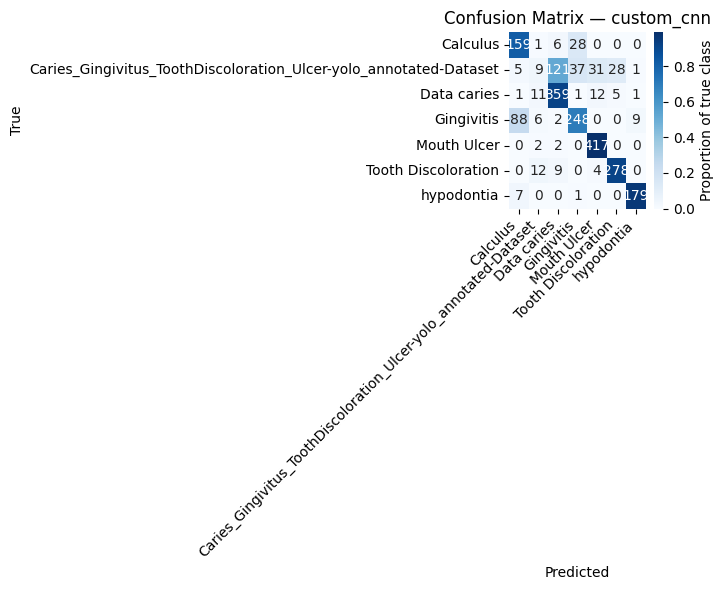

  accuracy=0.7928  macro_f1=0.7306  inference=4.78 ms/img

Evaluating MobileNetV2...


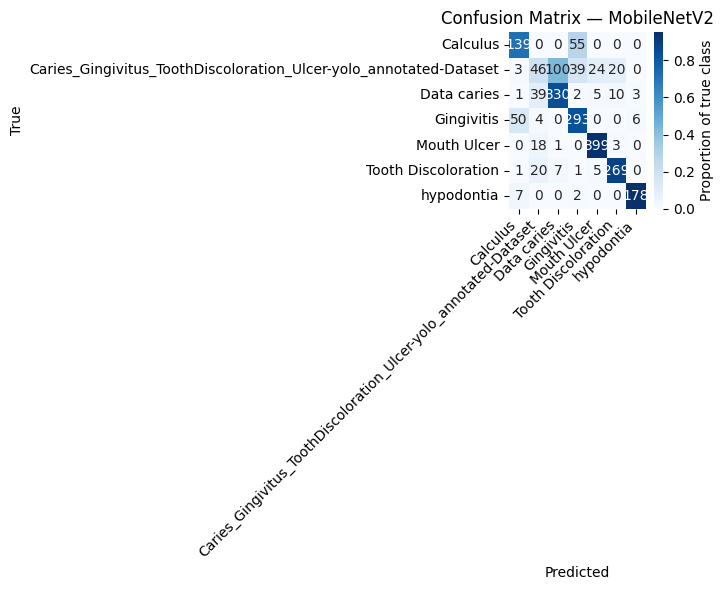

  accuracy=0.7952  macro_f1=0.7599  inference=5.27 ms/img

Evaluating EfficientNetB0...


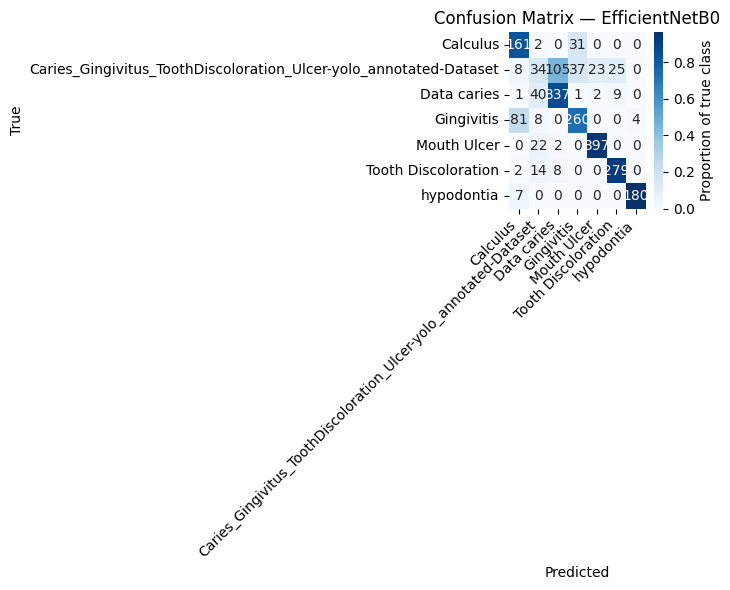

  accuracy=0.7923  macro_f1=0.7548  inference=6.44 ms/img

Evaluating ResNet50...


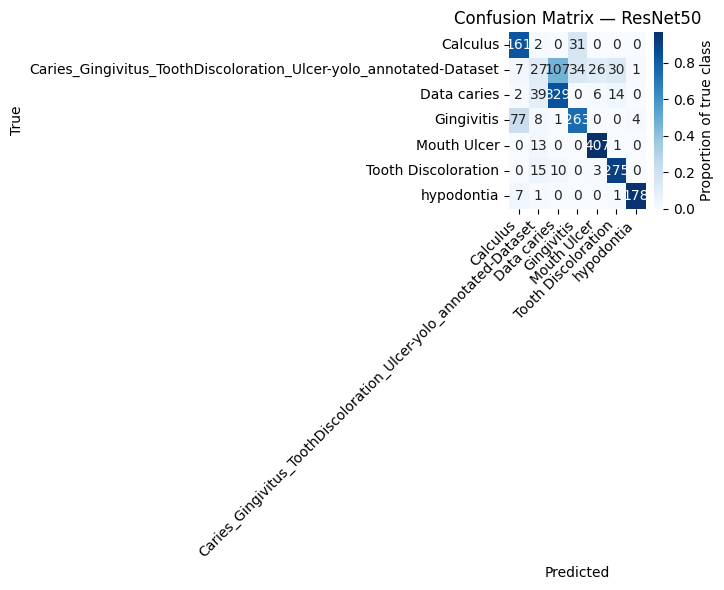

  accuracy=0.7885  macro_f1=0.7463  inference=5.92 ms/img



In [22]:

def evaluate_model(name, model, test_ds):
    y_true, y_pred = [], []
    t0=time.time(); n=0
    for x, y in test_ds:
        probs = model.predict(x, verbose=0)
        y_pred.append(np.argmax(probs, axis=1))
        y_true.append(y.numpy())
        n += x.shape[0]
    inference_ms = (time.time()-t0)/max(n,1)*1000
    y_true=np.concatenate(y_true); y_pred=np.concatenate(y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    acc = (y_true==y_pred).mean()
    return {"name":name, "accuracy":acc, "macro_f1":macro_f1, "weighted_f1":weighted_f1,
            "inference_ms_per_image":inference_ms, "params":model.count_params(),
            "report":report, "confusion_matrix":cm}

all_results = []
for name, model in trained_models.items():
    print(f"Evaluating {name}...")
    res = evaluate_model(name, model, test_ds)
    all_results.append(res)
    with open(os.path.join(REPORT_DIR, f"classification_report_{name}.json"), "w") as f:
        json.dump(res["report"], f, indent=2)

    fig, ax = plt.subplots(figsize=(7,6))
    cm = res["confusion_matrix"]
    cm_norm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, ax=ax, cbar_kws={"label":"Proportion of true class"})
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"Confusion Matrix — {name}")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"confusion_matrix_{name}.png"), dpi=150)
    plt.show()

    print(f"  accuracy={res['accuracy']:.4f}  macro_f1={res['macro_f1']:.4f}  "
          f"inference={res['inference_ms_per_image']:.2f} ms/img\n")


,name,accuracy,macro_f1,weighted_f1,inference_ms_per_image,params
1,MobileNetV2,0.795192,0.759900,0.781423,5.271743,2588743
0,custom_cnn,0.792788,0.730579,0.758156,4.782990,2399815
2,EfficientNetB0,0.792308,0.754777,0.777021,6.436036,4214954
3,ResNet50,0.788462,0.746331,0.769207,5.918412,24115079


/tmp/ipykernel_58/3408308074.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="name", y=col, ax=ax, palette="viridis")
/tmp/ipykernel_58/3408308074.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="name", y=col, ax=ax, palette="viridis")
/tmp/ipykernel_58/3408308074.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="name", y=col, ax=ax, palette="viridis")


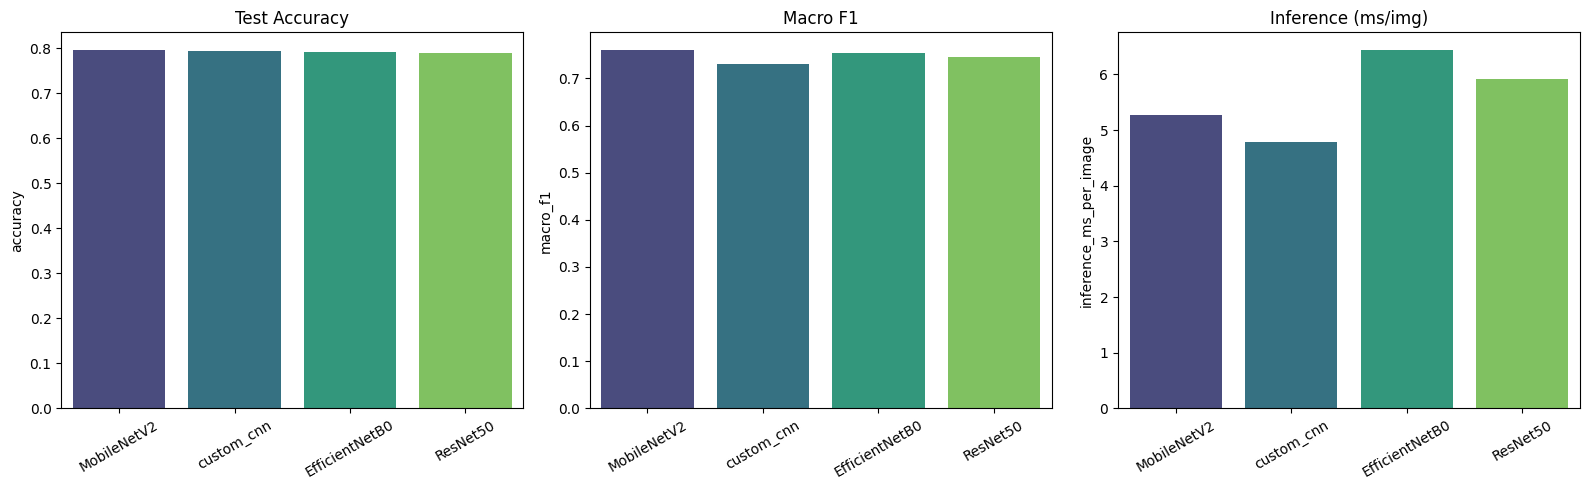

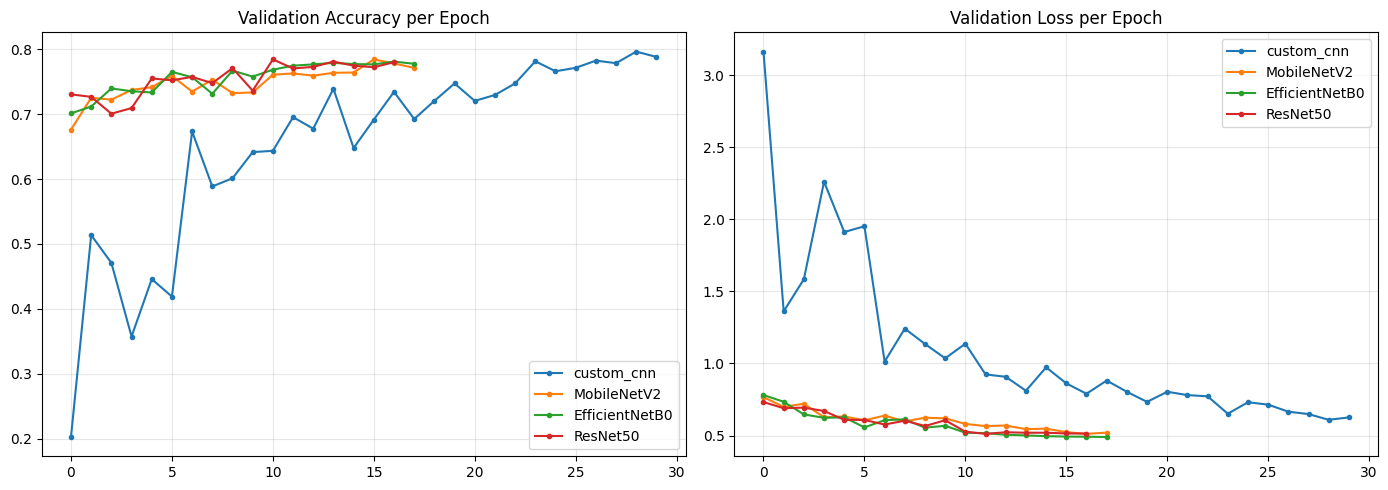


BEST MODEL: MobileNetV2  (test accuracy=0.7952)


In [23]:

df = pd.DataFrame([{
    "name": r["name"], "accuracy": r["accuracy"], "macro_f1": r["macro_f1"],
    "weighted_f1": r["weighted_f1"], "inference_ms_per_image": r["inference_ms_per_image"],
    "params": r["params"],
} for r in all_results]).sort_values("accuracy", ascending=False)

df.to_csv(os.path.join(REPORT_DIR, "model_comparison.csv"), index=False)
display(df)

fig, axes = plt.subplots(1,3, figsize=(16,5))
for ax,(col,title) in zip(axes, [("accuracy","Test Accuracy"),("macro_f1","Macro F1"),
                                   ("inference_ms_per_image","Inference (ms/img)")]):
    sns.barplot(data=df, x="name", y=col, ax=ax, palette="viridis")
    ax.set_title(title); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "model_comparison_bars.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1,2, figsize=(14,5))
for name, hist in histories.items():
    if "val_accuracy" in hist: axes[0].plot(hist["val_accuracy"], label=name, marker="o", markersize=3)
    if "val_loss" in hist: axes[1].plot(hist["val_loss"], label=name, marker="o", markersize=3)
axes[0].set_title("Validation Accuracy per Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Validation Loss per Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_curves_comparison.png"), dpi=150)
plt.show()

best_name = df.iloc[0]["name"]
best_info = {"name": best_name, "checkpoint": os.path.join(CKPT_DIR, f"{best_name}_final.keras"),
             "accuracy": float(df.iloc[0]["accuracy"]), "macro_f1": float(df.iloc[0]["macro_f1"]),
             "class_names": class_names, "img_size": IMG_SIZE}
with open(os.path.join(REPORT_DIR, "best_model.json"), "w") as f:
    json.dump(best_info, f, indent=2)
print(f"\nBEST MODEL: {best_name}  (test accuracy={best_info['accuracy']:.4f})")


## 11. Deployment — Gradio app

Loads the best model found above and serves an interactive classification UI. `share=True` gives you a public URL that works from Kaggle (valid for 72h) so you can demo it from any browser.

In [24]:

with open(os.path.join(REPORT_DIR, "best_model.json")) as f:
    BEST_INFO = json.load(f)

BEST_MODEL = tf.keras.models.load_model(BEST_INFO["checkpoint"])
CLASS_NAMES = BEST_INFO["class_names"]
IMG_SIZE_DEPLOY = BEST_INFO["img_size"]
MODEL_NAME = BEST_INFO["name"]
MODEL_ACCURACY = BEST_INFO["accuracy"]

CLASS_INFO = {
    "Calculus": "Hardened plaque (tartar) buildup on teeth, often near the gumline.",
    "Caries": "Tooth decay / cavities caused by acid-producing bacteria.",
    "Gingivitis": "Early-stage gum inflammation, often with redness and swelling.",
    "Hypodontia": "A developmental condition of one or more missing teeth.",
    "Tooth Discoloration": "Staining or color change of the tooth surface.",
    "Ulcers": "Mouth ulcers / sores on the soft tissue of the mouth.",
}

def preprocess(image):
    img = tf.image.resize(image, [IMG_SIZE_DEPLOY, IMG_SIZE_DEPLOY])
    img = tf.cast(img, tf.float32) / 255.0
    return tf.expand_dims(img, axis=0)

def make_confidence_plot(class_names, probs):
    order = np.argsort(probs)[::-1]
    names_sorted = [class_names[i] for i in order]
    probs_sorted = [probs[i] for i in order]
    fig, ax = plt.subplots(figsize=(6,3.6))
    colors = ["#2563eb" if i==0 else "#93c5fd" for i in range(len(probs_sorted))]
    bars = ax.barh(names_sorted[::-1], probs_sorted[::-1], color=colors[::-1])
    ax.set_xlim(0,1); ax.set_xlabel("Predicted probability")
    for bar,p in zip(bars, probs_sorted[::-1]):
        ax.text(min(p+0.02,0.9), bar.get_y()+bar.get_height()/2, f"{p*100:.1f}%", va="center", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    return fig

def predict(image):
    if image is None:
        return None, "Please upload an image.", ""
    x = preprocess(image)
    probs = BEST_MODEL.predict(x, verbose=0)[0]
    top_idx = int(np.argmax(probs)); top_class = CLASS_NAMES[top_idx]; top_conf = float(probs[top_idx])
    fig = make_confidence_plot(CLASS_NAMES, probs)
    headline = f"### 🦷 Prediction: **{top_class}** ({top_conf*100:.1f}% confidence)"
    order = np.argsort(probs)[::-1]
    top3 = [f"{i+1}. **{CLASS_NAMES[idx]}** — {probs[idx]*100:.1f}%" for i, idx in enumerate(order[:3])]
    details = f"{CLASS_INFO.get(top_class,'')}\n\n**Top differential:**\n\n" + "\n".join(top3)
    return fig, headline, details

THEME = gr.themes.Soft(primary_hue="blue", secondary_hue="cyan", neutral_hue="slate",
                        font=[gr.themes.GoogleFont("Inter"), "ui-sans-serif", "system-ui"])
CSS = '''
#header {text-align:center; padding:8px 0 4px 0;}
.disclaimer {background:#fef3c7; border:1px solid #fbbf24; border-radius:12px; padding:12px 16px; font-size:13px; color:#78350f; margin-top:8px;}
footer {visibility:hidden}
'''

with gr.Blocks(title="Oral Disease Classifier") as demo:
    gr.HTML(f'''<div id="header"><h1>🦷 Oral Disease Image Classifier</h1>
    <p>Upload an intraoral photo to classify it into one of {len(CLASS_NAMES)} categories,
    powered by <b>{MODEL_NAME}</b> (test accuracy: {MODEL_ACCURACY*100:.1f}%).</p></div>''')
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="numpy", label="Upload dental / intraoral image", height=320)
            with gr.Row():
                gr.ClearButton(components=[image_input], value="Clear")
                submit_btn = gr.Button("Classify", variant="primary")
            gr.HTML('''<div class="disclaimer">⚠️ <b>Not a medical device.</b> Educational /
            research demonstration only — not a substitute for professional dental diagnosis.
            Always consult a qualified dentist.</div>''')
        with gr.Column(scale=1):
            headline_output = gr.Markdown()
            plot_output = gr.Plot(label="Class probabilities")
            details_output = gr.Markdown()
    submit_btn.click(fn=predict, inputs=image_input, outputs=[plot_output, headline_output, details_output])
    image_input.change(fn=predict, inputs=image_input, outputs=[plot_output, headline_output, details_output])

demo.launch(share=True, theme=THEME, css=CSS)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://990a1e9a6e9c0e8624.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


2026-07-15 02:24:41.041197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 02:24:41.195681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-15 02:24:41.329012: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [25]:
import shutil
shutil.make_archive('output_files', 'zip', '/kaggle/working')


'/kaggle/working/output_files.zip'

In [29]:
from IPython.display import FileLink
FileLink('output_files.zip') # مثال: FileLink('output.csv')


/kaggle/working/output_files.zip